In [5]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv("fake_or_real_news.csv")
texts = df['text'].astype(str).values
labels = df['label'].values

# Encode labels (FAKE = 0, REAL = 1)
encoder = LabelEncoder()
labels = encoder.fit_transform(labels)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(texts, labels, test_size=0.2, random_state=42)

# Tokenize and pad sequences
max_words = 5000
max_len = 500

tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len)
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len)

# Build the RNN model
model = Sequential()
model.add(Embedding(input_dim=max_words, output_dim=64, input_length=max_len))
model.add(SimpleRNN(64))
model.add(Dense(1, activation='sigmoid'))

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

# Train the model and capture historyplt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], marker='o', linestyle='-', color='royalblue', label='Training Loss')
plt.plot(history.history['val_loss'], marker='s', linestyle='--', color='tomato', label='Validation Loss')
plt.title('Training vs Validation Loss Over Epochs', fontsize=16, fontweight='bold')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(range(len(history.history['loss'])))
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

history = model.fit(X_train_pad, y_train, epochs=5, batch_size=64, validation_data=(X_test_pad, y_test))


Epoch 1/5


D:\SHAMEEM\anaconda\Lib\site-packages\keras\src\layers\core\embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


80/80 ━━━━━━━━━━━━━━━━━━━━ 12s 104ms/step - accuracy: 0.5965 - loss: 0.6564 - val_accuracy: 0.6922 - val_loss: 0.5955
Epoch 2/5
80/80 ━━━━━━━━━━━━━━━━━━━━ 8s 99ms/step - accuracy: 0.8022 - loss: 0.4999 - val_accuracy: 0.7482 - val_loss: 0.4763
Epoch 3/5
80/80 ━━━━━━━━━━━━━━━━━━━━ 8s 99ms/step - accuracy: 0.9263 - loss: 0.2511 - val_accuracy: 0.8437 - val_loss: 0.3639
Epoch 4/5
80/80 ━━━━━━━━━━━━━━━━━━━━ 8s 99ms/step - accuracy: 0.9799 - loss: 0.0870 - val_accuracy: 0.8287 - val_loss: 0.3840
Epoch 5/5
80/80 ━━━━━━━━━━━━━━━━━━━━ 8s 101ms/step - accuracy: 0.9952 - loss: 0.0310 - val_accuracy: 0.8272 - val_loss: 0.4183


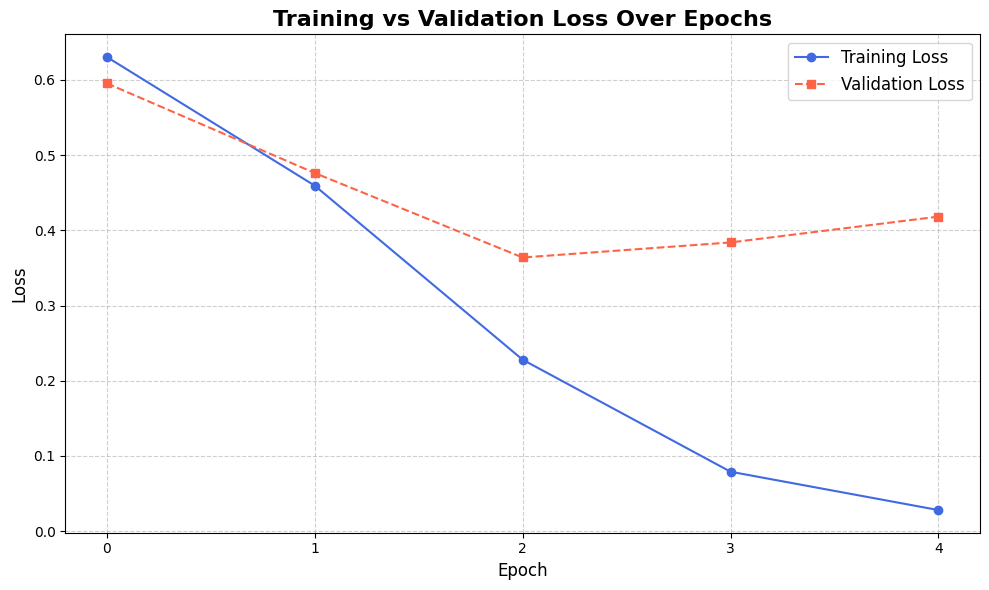

In [7]:
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], marker='o', linestyle='-', color='royalblue', label='Training Loss')
plt.plot(history.history['val_loss'], marker='s', linestyle='--', color='tomato', label='Validation Loss')
plt.title('Training vs Validation Loss Over Epochs', fontsize=16, fontweight='bold')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(range(len(history.history['loss'])))
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()
